Ethan Ho
017157582
CMPE 188

In [159]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score,roc_curve
import seaborn as sns

This is from the future but I notice my accuracy was 100% for my target column of `Overhype` and this is due to the fact that the dataset for finance sector only has 1 occurance of an overhyped company. I went back on kaggle and managed to download the same datasets for difference sectors. I will merge them into one big dataset and made sure to have the coloumns and data match up.

In [160]:
finance = pd.read_csv("E:/vs/school/CMPE_188/data/StartupFailureFinance.csv")
health = pd.read_csv("E:/vs/school/CMPE_188/data/StartupFailureHealth.csv")
manufacturer = pd.read_csv("E:/vs/school/CMPE_188/data/StartupFailureManufactures.csv")

# These two format their data as a little differently like "2 (2018-2020)" instead of "2018-2020" which I have to splice later
retail = pd.read_csv("E:/vs/school/CMPE_188/data/StartupFailureRetail.csv")
retail["Years of Operation"] = retail["Years of Operation"].str[0].astype(int)

info = pd.read_csv("E:/vs/school/CMPE_188/data/StartupFailuresInformation.csv")
info["Years of Operation"] = info["Years of Operation"].str[0].astype(int)

sectors = {
    "Finance And Insurance": finance,
    "HealthCare": health,
    "Manufacturers": manufacturer,
    "Retail Trade": retail,
    "Information Sector": info,
}

startup_data = pd.concat(sectors.values(), ignore_index=True)
startup_data.head()

,Name,Sector,Years of Operation,What They Did,How Much They Raised,Why They Failed,Takeaway,Giants,No Budget,Competition,Poor Market Fit,Acquisition Stagnation,Platform Dependency,Monetization Failure,Niche Limits,Execution Flaws,Trend Shifts,Toxicity/Trust Issues,Regulatory Pressure,Overhype
0,Avant,Finance and Insurance,2012-2023,Online personal loans,$655M,Lost to LendingClub and high defaults,Lending needs risk balance,1,1,1,0,0,0,0,0,0,0,0,0,0.0
1,Bitpass,Finance and Insurance,2002-2008,Micropayments platform,$2M,Lost to PayPal and low adoption,Micropayments need mass use,1,0,1,1,0,0,0,0,0,0,0,0,0.0
2,Cake Financial,Finance and Insurance,2006-2011,Portfolio tracking tool,$3M,Lost to Mint and sold to TradeKing,Finance tools need scale,1,0,1,0,1,0,0,0,0,0,0,0,0.0
3,Circle,Finance and Insurance,2013-2023,Crypto payments and stablecoin,$500M,Lost to Coinbase and market shifts,Crypto needs stability,1,0,1,0,0,0,0,0,0,1,0,0,0.0
4,Clarity Money,Finance and Insurance,2016-2022,Personal finance app,$11M,Lost to Mint/Acorns and sold to Goldman,Finance apps need edge,1,0,1,0,1,0,0,0,0,0,0,0,0.0


In [161]:
startup_data.describe()

,Giants,No Budget,Competition,Poor Market Fit,Acquisition Stagnation,Platform Dependency,Monetization Failure,Niche Limits,Execution Flaws,Trend Shifts,Toxicity/Trust Issues,Regulatory Pressure,Overhype
count,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,382.000000
mean,0.751958,0.185379,0.707572,0.195822,0.227154,0.018277,0.143603,0.172324,0.151436,0.109661,0.060052,0.036554,0.052356
std,0.432441,0.389113,0.455473,0.397352,0.419541,0.134126,0.351146,0.378156,0.358942,0.312875,0.237894,0.187908,0.223036
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [162]:
startup_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    383 non-null    object 
 1   Sector                  383 non-null    object 
 2   Years of Operation      383 non-null    object 
 3   What They Did           383 non-null    object 
 4   How Much They Raised    383 non-null    object 
 5   Why They Failed         383 non-null    object 
 6   Takeaway                383 non-null    object 
 7   Giants                  383 non-null    int64  
 8   No Budget               383 non-null    int64  
 9   Competition             383 non-null    int64  
 10  Poor Market Fit         383 non-null    int64  
 11  Acquisition Stagnation  383 non-null    int64  
 12  Platform Dependency     383 non-null    int64  
 13  Monetization Failure    383 non-null    int64  
 14  Niche Limits            383 non-null    in

I decided to remove the `Name` coloum as it has no relavance and the sector column because all the companies in the dataset were in the same sector. For the `How Much They Raised` column, I filtered out the integer and kept it for the column. The `Years of Operation` I decided to just subtract the ending year by the starting to turn it into a numerical column as well. The rest of the categorical data I decided to encode and figure out if they were correlated. I then removed `Competition` and `Platform Dependency` as they were all the same. `Overhyped` also has a single NaN row so I removed it.

In [163]:
df = startup_data.drop(["Name", "Competition", "Platform Dependency"], axis=1)

# Extracted the regex for any number of decimal numbers for the col
df["How Much They Raised"] = df["How Much They Raised"].str.extract('(\d+)', expand=False).fillna(0).astype(int)

# Subtracted the ending year by the starting
df["Years of Operation"] = df["Years of Operation"].apply(lambda x: int(x.split("-")[1]) - int(x.split("-")[0]) if type(x) == str else x)

df = df.dropna()

df.head()

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Admin\AppData\Local\Temp\ipykernel_5356\2970703537.py:4: SyntaxWarning: invalid escape sequence '\d'
  df["How Much They Raised"] = df["How Much They Raised"].str.extract('(\d+)', expand=False).fillna(0).astype(int)


,Sector,Years of Operation,What They Did,How Much They Raised,Why They Failed,Takeaway,Giants,No Budget,Poor Market Fit,Acquisition Stagnation,Monetization Failure,Niche Limits,Execution Flaws,Trend Shifts,Toxicity/Trust Issues,Regulatory Pressure,Overhype
0,Finance and Insurance,11,Online personal loans,655,Lost to LendingClub and high defaults,Lending needs risk balance,1,1,0,0,0,0,0,0,0,0,0.0
1,Finance and Insurance,6,Micropayments platform,2,Lost to PayPal and low adoption,Micropayments need mass use,1,0,1,0,0,0,0,0,0,0,0.0
2,Finance and Insurance,5,Portfolio tracking tool,3,Lost to Mint and sold to TradeKing,Finance tools need scale,1,0,0,1,0,0,0,0,0,0,0.0
3,Finance and Insurance,10,Crypto payments and stablecoin,500,Lost to Coinbase and market shifts,Crypto needs stability,1,0,0,0,0,0,0,1,0,0,0.0
4,Finance and Insurance,6,Personal finance app,11,Lost to Mint/Acorns and sold to Goldman,Finance apps need edge,1,0,0,1,0,0,0,0,0,0,0.0


In [164]:
df.isnull().sum()

Sector                    0
Years of Operation        0
What They Did             0
How Much They Raised      0
Why They Failed           0
Takeaway                  0
Giants                    0
No Budget                 0
Poor Market Fit           0
Acquisition Stagnation    0
Monetization Failure      0
Niche Limits              0
Execution Flaws           0
Trend Shifts              0
Toxicity/Trust Issues     0
Regulatory Pressure       0
Overhype                  0
dtype: int64

In [165]:
encoder = LabelEncoder()

df["Sector"] = encoder.fit_transform(df["Sector"])
df["What They Did"] = encoder.fit_transform(df["What They Did"])
df["Why They Failed"] = encoder.fit_transform(df["Why They Failed"])
df["Takeaway"] = encoder.fit_transform(df["Takeaway"])

df.head()

,Sector,Years of Operation,What They Did,How Much They Raised,Why They Failed,Takeaway,Giants,No Budget,Poor Market Fit,Acquisition Stagnation,Monetization Failure,Niche Limits,Execution Flaws,Trend Shifts,Toxicity/Trust Issues,Regulatory Pressure,Overhype
0,0,11,239,655,186,163,1,1,0,0,0,0,0,0,0,0,0.0
1,0,6,204,2,194,187,1,0,1,0,0,0,0,0,0,0,0.0
2,0,5,272,3,189,98,1,0,0,1,0,0,0,0,0,0,0.0
3,0,10,66,500,166,47,1,0,0,0,0,0,0,1,0,0,0.0
4,0,6,256,11,190,95,1,0,0,1,0,0,0,0,0,0,0.0


In [166]:
df.describe()

,Sector,Years of Operation,What They Did,How Much They Raised,Why They Failed,Takeaway,Giants,No Budget,Poor Market Fit,Acquisition Stagnation,Monetization Failure,Niche Limits,Execution Flaws,Trend Shifts,Toxicity/Trust Issues,Regulatory Pressure,Overhype
count,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000
mean,2.151832,5.253927,186.746073,93.955497,187.413613,184.746073,0.751309,0.185864,0.196335,0.227749,0.143979,0.172775,0.151832,0.109948,0.060209,0.036649,0.052356
std,1.280987,3.270150,107.478477,173.160404,109.437054,106.198230,0.432821,0.389507,0.397746,0.419930,0.351529,0.378548,0.359329,0.313235,0.238186,0.188145,0.223036
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,3.000000,94.250000,4.000000,92.250000,93.250000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,5.000000,187.500000,20.000000,187.500000,186.500000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.000000,7.000000,278.750000,94.250000,281.750000,274.750000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,4.000000,18.000000,372.000000,950.000000,377.000000,369.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


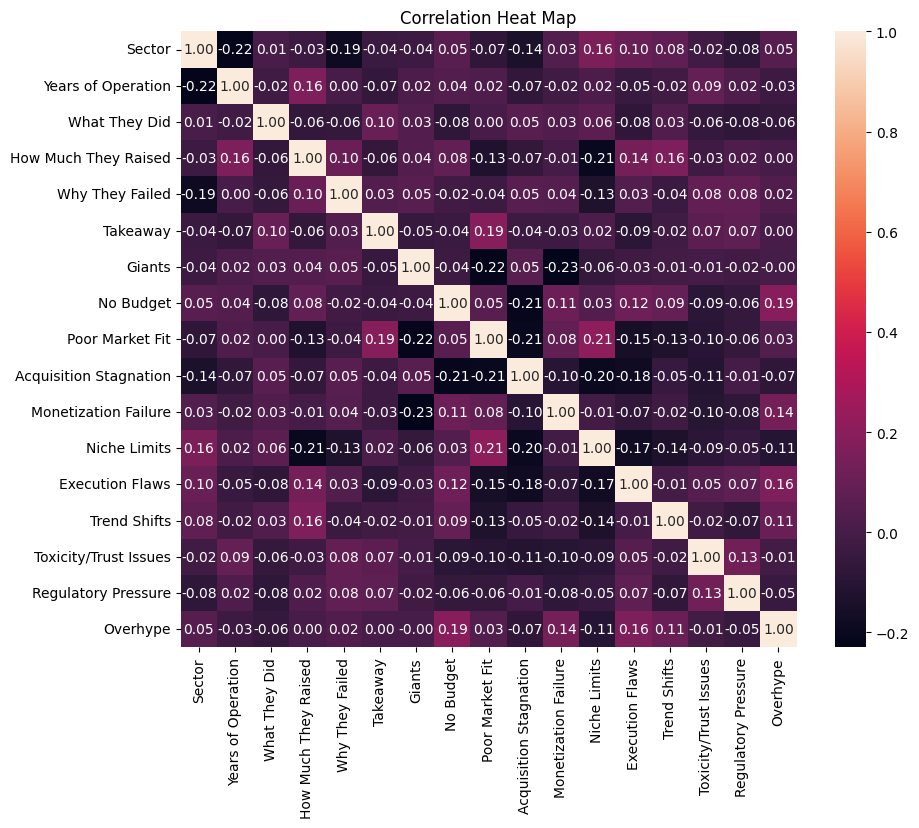

In [167]:
plt.figure(figsize=(10,8))
corr_map = df.corr("pearson")
sns.heatmap(corr_map, square=True, annot=True, fmt='.2f')
plt.title("Correlation Heat Map")
plt.show()

In [168]:
df.corr()['Overhype']

Sector                    0.045596
Years of Operation       -0.032670
What They Did            -0.060759
How Much They Raised      0.004070
Why They Failed           0.024918
Takeaway                  0.004220
Giants                   -0.000712
No Budget                 0.189816
Poor Market Fit           0.031755
Acquisition Stagnation   -0.071599
Monetization Failure      0.137937
Niche Limits             -0.107421
Execution Flaws           0.162548
Trend Shifts              0.105233
Toxicity/Trust Issues    -0.010088
Regulatory Pressure      -0.045846
Overhype                  1.000000
Name: Overhype, dtype: float64

After encoding the three categoical coloumns did not seem to have too much correlation, especially the `What They Did` but I decided to keep them and let the trees decide.

### Splitting Data

I decided to have `Overhype` as the output so that the model can try to predict whether the model was a good idea or not.

In [169]:
x = df.drop(["Overhype"], axis=1)
y = pd.DataFrame(df["Overhype"])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20)

print(y_train.head())
print(x_train.head())

     Overhype
228       0.0
184       0.0
107       0.0
279       0.0
340       1.0
     Sector  Years of Operation  What They Did  How Much They Raised  \
228       2                   1             98                    20   
184       4                   9            169                    60   
107       3                   7             93                    70   
279       2                   1            328                    12   
340       2                   4            205                     1   

     Why They Failed  Takeaway  Giants  No Budget  Poor Market Fit  \
228              136       152       1          0                0   
184              118        16       1          0                0   
107              169        70       1          1                0   
279               84       360       1          0                0   
340               91       138       0          1                1   

     Acquisition Stagnation  Monetization Failure  Niche Limit

### Trees

In [170]:
# Decision Tree
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(x_train, y_train)
decision_tree_predict = decision_tree.predict(x_test)
print("Decision Tree Score: ", accuracy_score(y_test, decision_tree_predict))

# Bagging Classifier
bagging_tree = BaggingClassifier(
    DecisionTreeClassifier(random_state=42),
    # n_estimators=500,
    # max_samples=100,
    # bootstrap=True,
    # n_jobs=-1,
    random_state=42
    )
bagging_tree.fit(x_train, y_train)
bagging_tree_predict = bagging_tree.predict(x_test)
print("Decision Tree Score: ", accuracy_score(y_test, bagging_tree_predict))

# Random Forrest
random_forrest = RandomForestClassifier(
    # n_estimators=500, 
    # max_leaf_nodes=16, 
    # n_jobs=-1, 
    random_state=42)
random_forrest.fit(x_train, y_train)
random_forrest_predict = random_forrest.predict(x_test)
random_forrest_prob = random_forrest.predict_proba(x_test)
print("Decision Tree Score: ", accuracy_score(y_test, random_forrest_predict))


Decision Tree Score:  0.922077922077922
Decision Tree Score:  0.948051948051948


c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\ensemble\_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Decision Tree Score:  0.948051948051948


C:\Users\Admin\AppData\Local\Temp\ipykernel_5356\4123933484.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


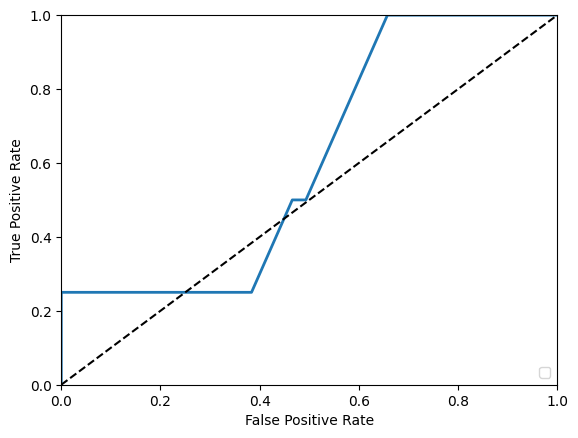

In [171]:
# Random Forrest ROC Curve

random_forrest_score = random_forrest_prob[:,1]
fpr_rf,tpr_rf, threshold_rf = roc_curve(y_test, random_forrest_score)

def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr,tpr, linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    
plot_roc_curve(fpr_rf,tpr_rf)
plt.legend(loc="lower right")
plt.show()

c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expecte

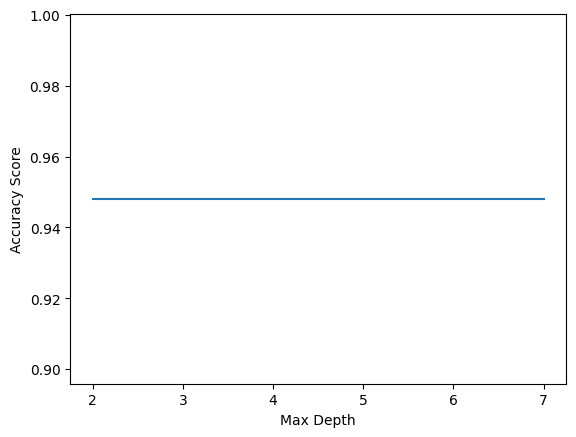

In [172]:
# Tuning Random Forrest Depth Parameter
scores = []
for i in range(2, 8):
    random_forrest = RandomForestClassifier(
    # n_estimators=500, 
    # max_leaf_nodes=16, 
    # n_jobs=-1, 
    max_depth=i,
    random_state=42)
    random_forrest.fit(x_train, y_train)
    random_forrest_predict = random_forrest.predict(x_test)
    scores.append(accuracy_score(y_test, random_forrest_predict))

plt.plot(range(2, 8), scores)
plt.xlabel("Max Depth")
plt.ylabel("Accuracy Score")
plt.show()

The accuracy of the model didn't seem to improve with an increase of depth contrary to what I thought. This may be due to the limited columns and data presented in our dataset.

### AdaBoosting

c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.

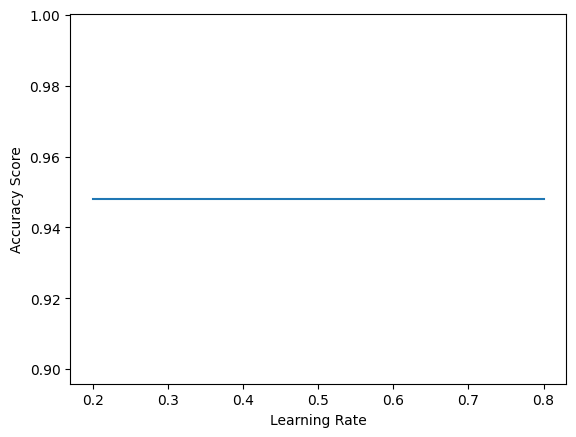

In [176]:
adaScores = []
rates = [0.2, 0.3, 0.4, 0.5, 0.6, 0.8]
for i in rates:
    ada_boost = AdaBoostClassifier(
        DecisionTreeClassifier(max_depth=1), n_estimators=200,
        algorithm="SAMME", learning_rate=i, random_state=42)
    ada_boost.fit(x_train, y_train)

    y_pred_ada = ada_boost.predict(x_test)
    adaScores.append(accuracy_score(y_test, y_pred_ada))

plt.plot(rates, scores)
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy Score")
plt.show()

Again, we see that the accuracy doesnt improve due to our dataset.

### CrossValidation

c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\ensemble\_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\ensemble\_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\ensemble\_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\ensemble\_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was e

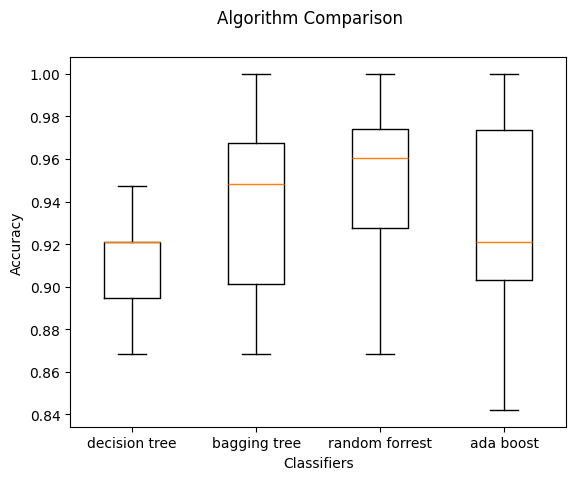

In [174]:
results = []
models = [decision_tree, bagging_tree, random_forrest, ada_boost]
names = ["decision tree", "bagging tree", "random forrest", "ada boost"]

for model in models:
	kfold = KFold(n_splits=10) 
	cv_results = cross_val_score(model, x, y, cv=kfold, scoring='accuracy')
	results.append(cv_results)

# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.xlabel("Classifiers")
plt.ylabel("Accuracy")
plt.show()

From the cross validation results we can see that in general the ensemble techniques have better accuracy than a lone decision tree. However that also means an increase in variability which means uncertainty in its prediction. We can see all three techniques hit 100% accuracy which random forrest having a slightly larger median while the decision tree under performs but has lower variance. 